# Compare the peak to trough ratios of our deconvolution runs

1. Load the model 
2. Load the raw data
3. Load the deconvolved data
4. Compute the peak to trough ratio
5. Load the published peak to trough ratio values
6. Plot the comparison between the peak to trough ratios


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os


In [3]:
from cc_src.deconvolution_analysis import DeconvolvedAnalysis
from src.config import Config, load_xg_gene_expression_config
from src.model import Model

In [247]:
pd.DataFrame.from_dict(deconvolved_analysis.model.config.orf_index_map.items())

,0,1
0,YPR161C,0
1,YOL138C,1
2,YDR395W,2
3,YGR129W,3
4,YPR165W,4
...,...,...
5666,YEL035C,5666
5667,YOR020C,5667
5668,YLL053C,5668
5669,YDR314C,5669


In [248]:
model.config.orf_index_map[orf_name]

4810

In [252]:
model = Model(config, gene_name, gamma)

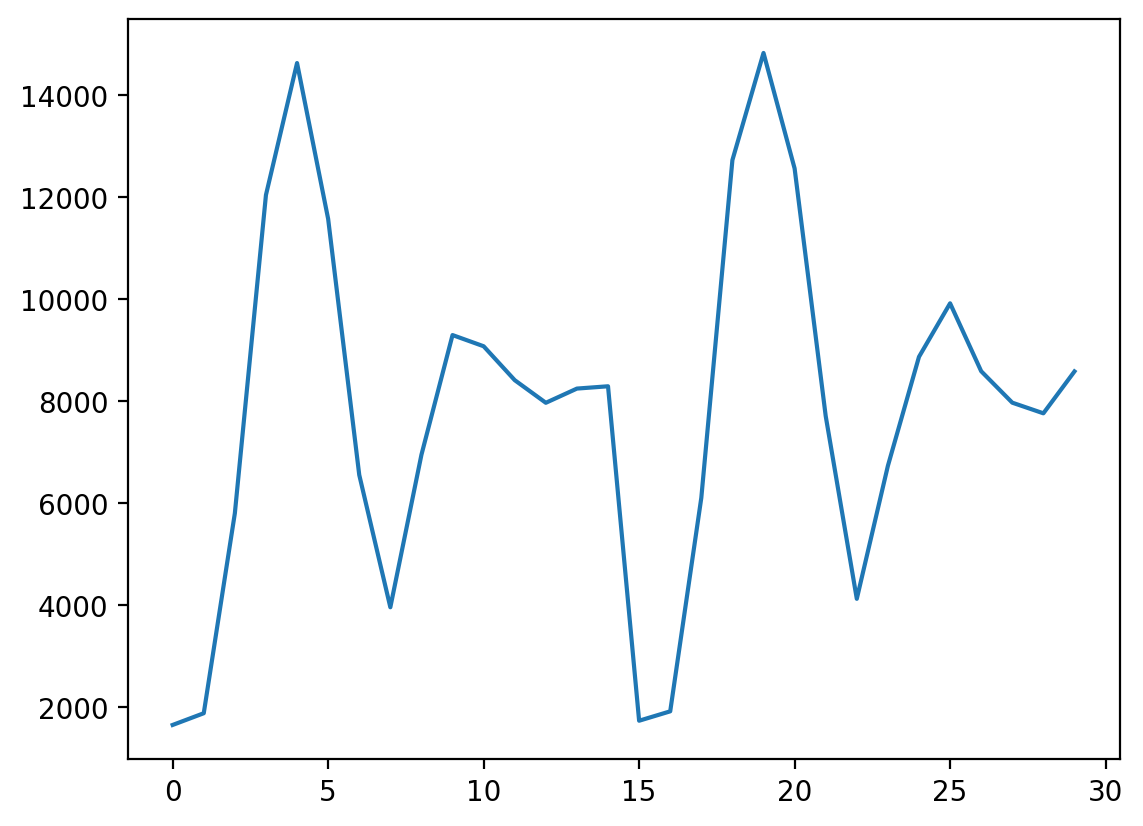

In [254]:
plt.plot(model.g)

In [371]:
# from cc_src.sgd import read_sgd_genes

# # Currently trying to fix the ordering of the gene set list and the f matrix ordering.
# genes = read_sgd_genes()[['gene']]

# genelist = pd.read_csv('allgenes/commongenelist.txt', sep='\t', header=None)
# genelist.columns = ['gene']
# genelist = genelist.set_index('gene')
# genelist['idx'] = np.arange(len(genelist))

# genes.loc[genes.gene.isna(), 'gene'] = genes[genes.gene.isna()].index.values
# genes = genes.reset_index().set_index('gene')

# # This list will preserve the ordering in which genes were deconvolved and how we will
# # know what row belongs to which in the f matrix.
# genelist_orfmapping = genes.join(genelist, how='right').reset_index()
# genelist_orfmapping

In [372]:
# f = deconvolved_analysis.f.copy()
# keepcols = f.columns
# f = f.reset_index()[keepcols]
# f.index = genelist_orfmapping.orf_name
# deconvolved_analysis.f = f

In [402]:
from cc_src.sgd import get_orfname

gene_name = 'TKL2'
orf_name = get_orfname(gene_name)
gamma = 0.004

config = load_xg_gene_expression_config()
model = Model(config, gene_name, gamma)

In [412]:
model.config.ordered_orf_names

array(['YPR161C', 'YOL138C', 'YDR395W', ..., 'YOR020C', 'YLL053C', nan],
      dtype=object)

In [429]:
deconvolved_analysis.f

,0,1,2,3,4,5,6,7,8,9,...,248,249,250,251,252,253,254,255,256,257
orf_name,,,,,,,,,,,,,,,,,,,,,
YPR161C,1132.679967,1132.798232,1133.037664,1133.404119,1133.904363,1134.553868,1135.368808,1136.336997,1137.472712,1138.868168,...,1556.743743,1568.849971,1581.295639,1594.012355,1607.012057,1619.805468,1632.295363,1645.596762,1659.638992,1674.287199
YOL138C,1683.719759,1683.708509,1683.685923,1683.651656,1683.605350,1683.546938,1683.475876,1683.390919,1683.291614,1683.176742,...,1649.560295,1650.639700,1651.638039,1652.494247,1653.214776,1653.690328,1653.921642,1654.149951,1654.236041,1654.277496
YDR395W,408.663703,410.182494,413.229859,417.824703,423.986945,431.775225,441.243982,452.320913,465.052439,479.800919,...,4985.716495,4977.794665,4970.211568,4962.378863,4954.206002,4946.396427,4939.200644,4931.356060,4921.352057,4916.339849
YGR129W,1769.880445,1769.644605,1769.172020,1768.462671,1767.514843,1766.322075,1764.883213,1763.188029,1761.234860,1759.037333,...,1010.524442,1018.796485,1026.523346,1034.140847,1041.501476,1048.847486,1055.880546,1061.733619,1066.148079,1068.436552
YPR165W,12135.902232,12135.342669,12134.205971,12132.512780,12130.252951,12127.241499,12123.427332,12118.981119,12113.865333,12107.923501,...,11251.133265,11207.482183,11159.985433,11109.834026,11055.117545,11003.367380,10954.943933,10884.758899,10792.799297,10683.704697
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YPL268W,1213.033232,1213.195831,1213.522333,1214.015261,1214.677251,1215.516181,1216.539322,1217.736881,1219.115043,1220.722400,...,1443.347205,1441.116056,1438.921983,1436.603996,1434.182979,1431.928172,1429.880095,1428.121344,1426.095003,1425.090730
YEL035C,276.641689,276.658623,276.692548,276.743523,276.811644,276.897339,277.000891,277.121803,277.260297,277.418187,...,352.644838,352.663838,352.690462,352.735258,352.807832,352.854361,352.853129,352.991129,353.281195,353.424932
YOR020C,16093.522992,16091.738854,16088.171823,16082.824431,16075.701165,16066.805309,16056.142209,16043.730568,16029.580246,16013.677590,...,12617.830415,12662.640290,12706.763398,12748.961430,12788.212123,12826.980910,12866.017217,12893.647243,12912.959339,12922.906074


In [426]:
foo = deconvolved_analysis.f[[]].copy()
foo['idx'] = np.arange(len(foo))
foo.loc[orf_name]

idx    4809
Name: YBR117C, dtype: int64

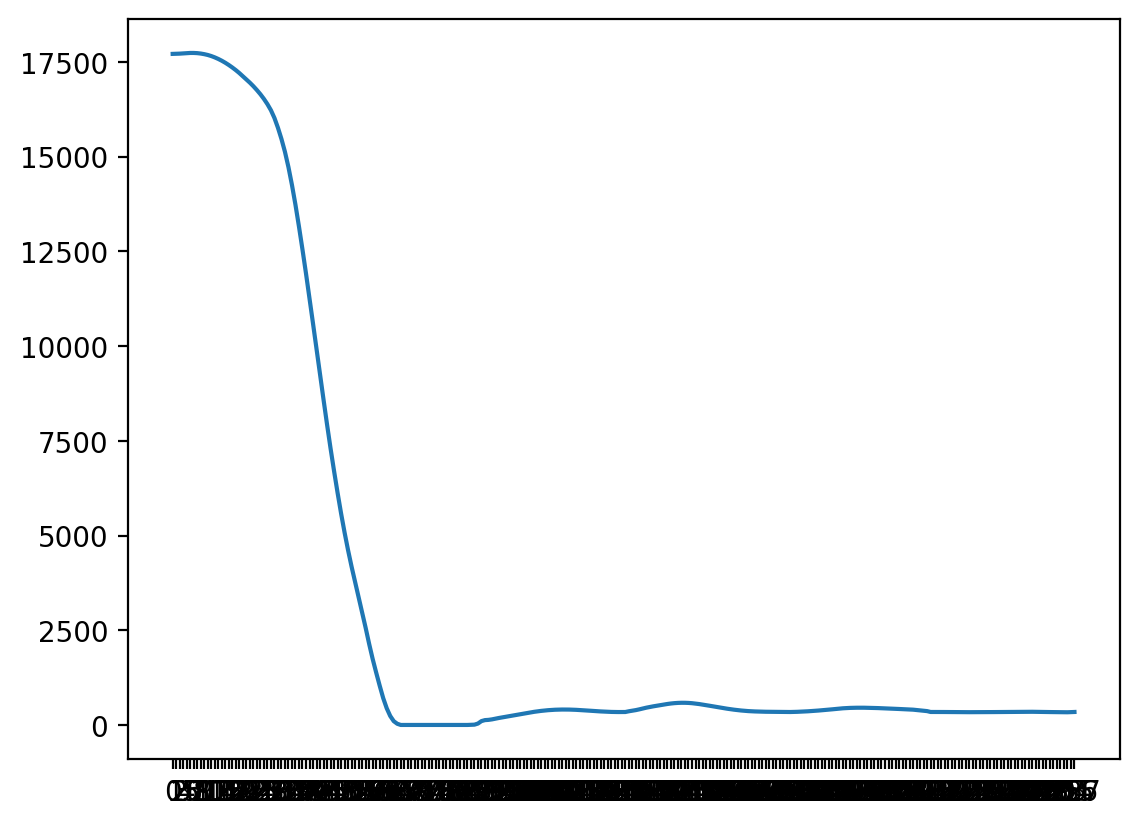

In [428]:
plt.plot(deconvolved_analysis.f.iloc[4810])

YBR117C


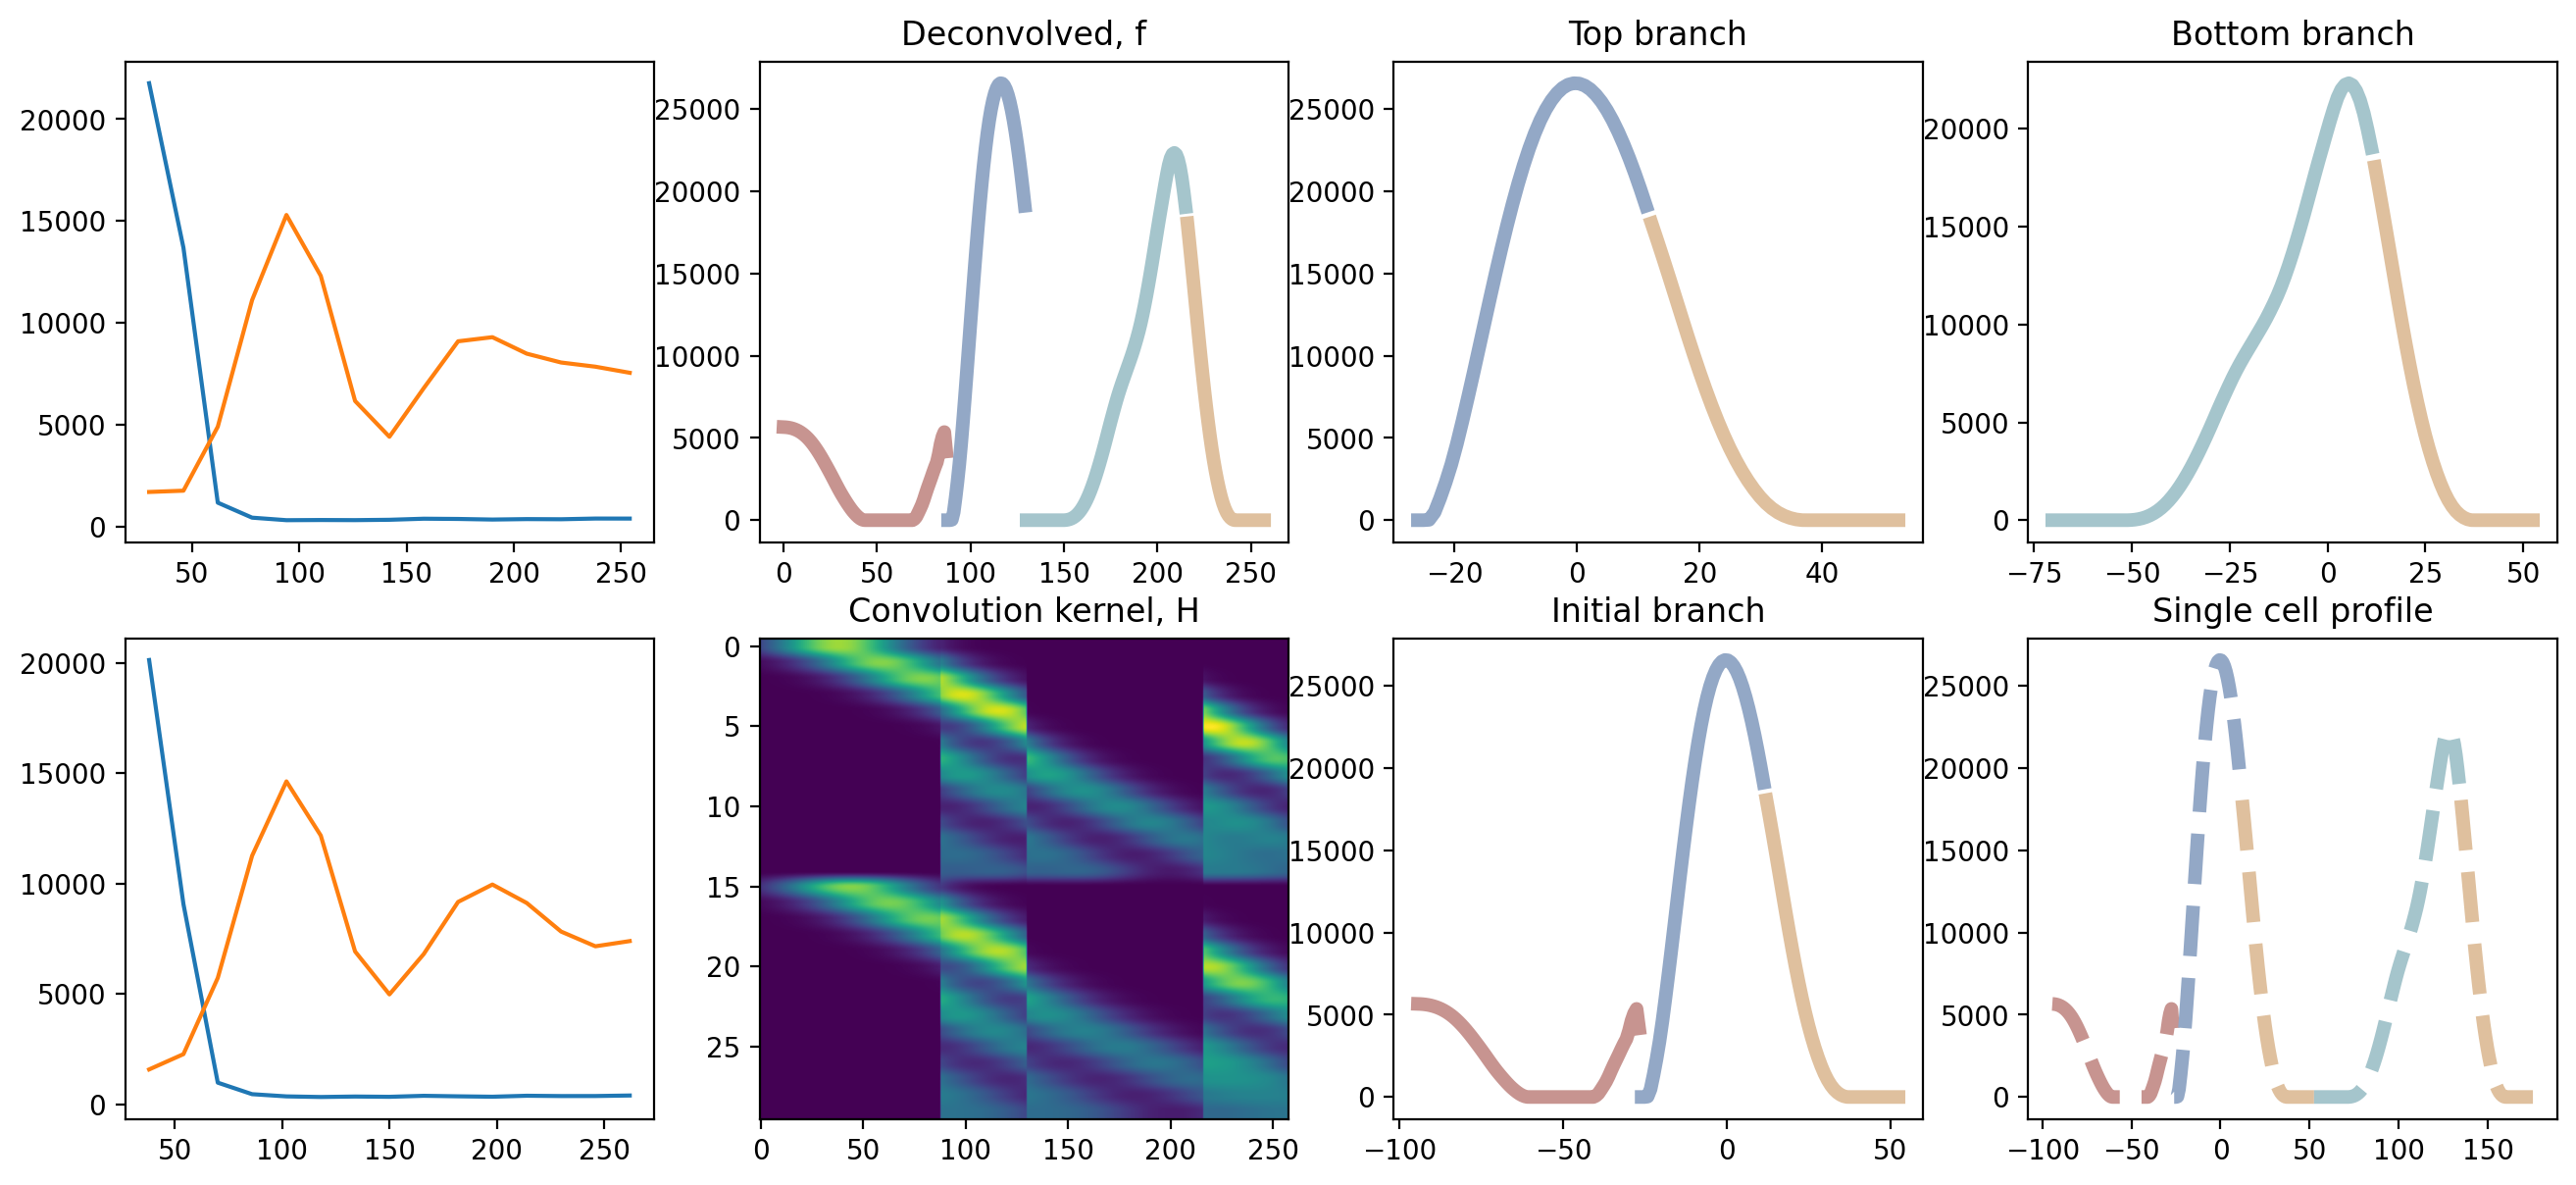

In [393]:
deconvolved_analysis = DeconvolvedAnalysis(model)
deconvolved_analysis.plot_deconvolved_gene(gene_name)

In [12]:
genelist = pd.read_csv('allgenes/commongenelist.txt',sep='\t', header=None)[0].values

In [28]:
gene_f = deconvolved_analysis.f.loc[orf_name].values

In [134]:
ptrs = deconvolved_analysis.f[[]].copy()

for orf_name, row in deconvolved_analysis.f.iterrows():
    
    dec_ptr = compute_ptr(row)
    ptrs.loc[orf_name, 'ptr'] = dec_ptr


ptrs.head()

,ptr
orf_name,
YPR161C,1.204751
YOL138C,1.051088
YDR395W,1.122499
YGR129W,1.541353
YPR165W,1.255229


In [94]:
matlab_fs = pd.read_csv('../deconvolution-project/output/2023-11-27_xg_deconv2_gammas/'\
                        'all_genes_f.csv', header=None)
matlab_gs.index = deconvolved_analysis.f.index
matlab_gs = pd.read_csv('../deconvolution-project/output/2023-11-27_xg_deconv2_gammas/'\
                        'all_genes_g.csv', header=None)
matlab_fs.index = deconvolved_analysis.f.index

In [123]:
# matlab_f = matlab_fs.loc[orf_name]
# plt.plot(matlab_f)
# plt.plot(gene_f)

In [103]:
gene_table_path = '/Users/trung/Research/cell-cycle/data/dataset_from_deconv_web/gene_associated.tsv';
gene_table = pd.read_csv(gene_table_path, sep='\t');
gene_table = gene_table[['Systematic Name', 'Deconvolved PTR (80pt/20pt)']].set_index('Systematic Name')
gene_table.head(2)

,Deconvolved PTR (80pt/20pt)
Systematic Name,
YKR013W,14716.721
YIL140W,7425.072


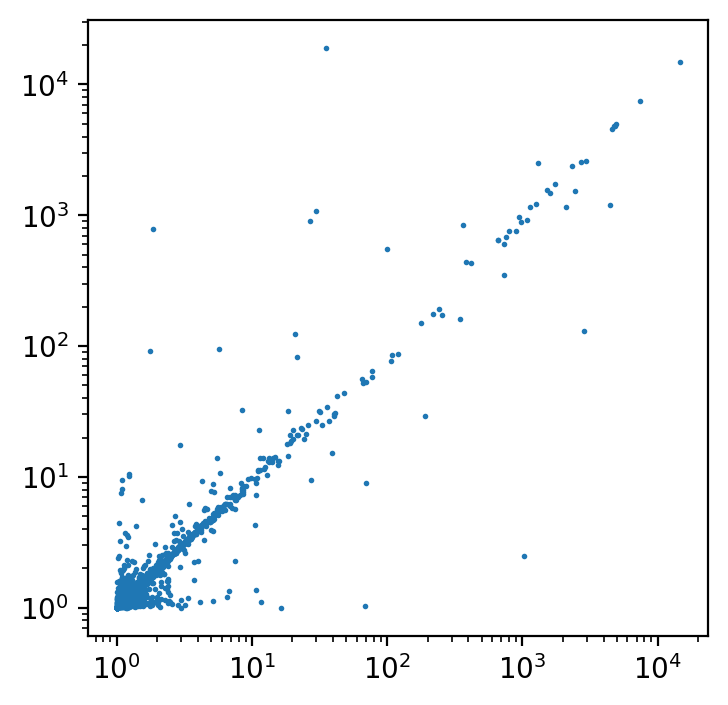

In [141]:
plt_data = gene_table.join(ptrs)

plt.figure(figsize=(4, 4))
plt.scatter(plt_data['Deconvolved PTR (80pt/20pt)'], plt_data.ptr, s=1)
plt.xscale('log')
plt.yscale('log')

# a decent set of genes with different PTR values, wonder if it's the scaling thing, maybe something else.
# We can investigate tomorrow.


In [182]:
matlab_peaktotroughts = pd.read_csv('../deconvolution-project/output/2023-11-27_xg_deconv2_gammas/peak2troughs.csv', header=None)
matlab_peaktotroughts.index = deconvolved_analysis.f.index
matlab_peaktotroughts.columns = ['ptr']

In [184]:
comparison_ptrs_py_matlab = ptrs.join(matlab_peaktotroughts, lsuffix='_py', rsuffix='_matlab')

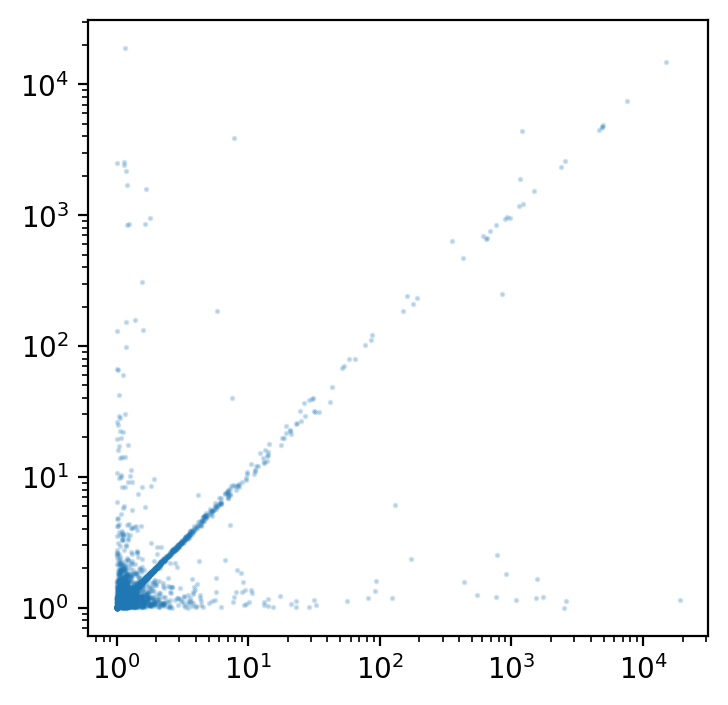

In [190]:
plt.figure(figsize=(4, 4))
plt.scatter(comparison_ptrs_py_matlab.ptr_py, 
            comparison_ptrs_py_matlab.ptr_matlab, s=1, alpha=0.2)
plt.xscale('log')
plt.yscale('log')



In [191]:
comparison_ptrs_py_matlab.ptr_py.corr(comparison_ptrs_py_matlab.ptr_matlab)

0.4920997421426804

In [194]:
comparison_ptrs_py_matlab['diff'] = comparison_ptrs_py_matlab.ptr_py - comparison_ptrs_py_matlab.ptr_matlab

In [200]:
from cc_src.sgd import read_sgd_genes

genes = read_sgd_genes()[['gene']]

In [201]:
comparison_ptrs_py_matlab.sort_values('diff').join(genes)

,ptr_py,ptr_matlab,diff,gene
orf_name,,,,
YBR117C,1.151765,19093.787116,-19092.635350,TKL2
YPL141C,7.756021,3897.655383,-3889.899362,FRK1
YBL035C,1205.847437,4420.186882,-3214.339445,POL12
YJR105W,1.130963,2561.478474,-2560.347511,ADO1
YEL054C,1.003519,2491.414025,-2490.410507,RPL12A
...,...,...,...,...
YDL227C,1573.908748,1.671741,1572.237007,HO
YNR067C,1745.906992,1.201600,1744.705391,DSE4
YEL076C-A,2516.564246,1.003539,2515.560707,None


In [220]:
gene_table.columns = ['web_ptr']
web_ptr_table = gene_table

comparison_ptrs_py_matlab_web = comparison_ptrs_py_matlab.join(web_ptr_table)

Text(0, 0.5, 'Published PTR')

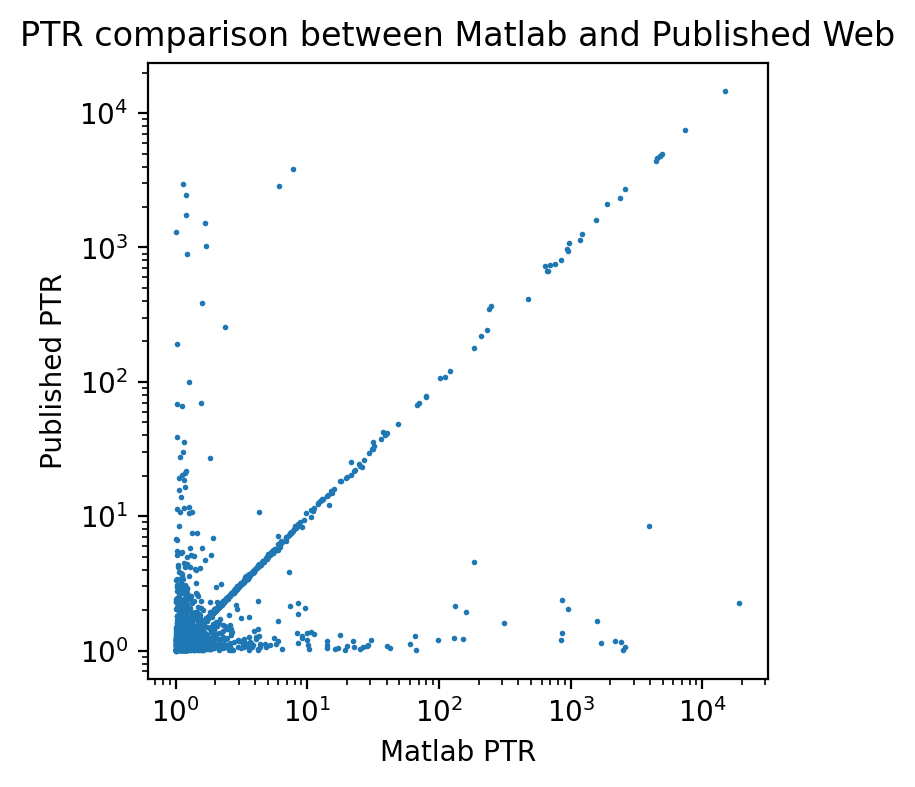

In [229]:
plt.figure(figsize=(4,4))
plt.scatter(comparison_ptrs_py_matlab_web.ptr_matlab, 
            comparison_ptrs_py_matlab_web.web_ptr, s=1)
plt.xscale('log')
plt.yscale('log')
plt.title('PTR comparison between Matlab and Published Web')
plt.xlabel("Matlab PTR")
plt.ylabel("Published PTR")

In [232]:
comparison_ptrs_py_matlab_web['web_matlab_diff'] = comparison_ptrs_py_matlab_web.web_ptr \
- comparison_ptrs_py_matlab_web.ptr_matlab

In [235]:
comparison_ptrs_py_matlab_web.sort_values('web_matlab_diff').join(genes)

,ptr_py,ptr_matlab,diff,web_ptr,web_matlab_diff,gene
orf_name,,,,,,
YBR117C,1.151765,19093.787116,-19092.635350,2.275,-19091.512116,TKL2
YPL141C,7.756021,3897.655383,-3889.899362,8.437,-3889.218383,FRK1
YJR105W,1.130963,2561.478474,-2560.347511,1.068,-2560.410474,ADO1
YEL054C,1.003519,2491.414025,-2490.410507,1.009,-2490.405025,RPL12A
YNL038W,1.144385,2411.206376,-2410.061991,1.155,-2410.051376,GPI15
...,...,...,...,...,...,...
YNR067C,1745.906992,1.201600,1744.705391,1740.576,1739.374400,DSE4
YHR143W,1538.531199,1.189829,1537.341370,2445.479,2444.289171,DSE2
YOL007C,129.798965,6.114039,123.684926,2847.574,2841.459961,CSI2


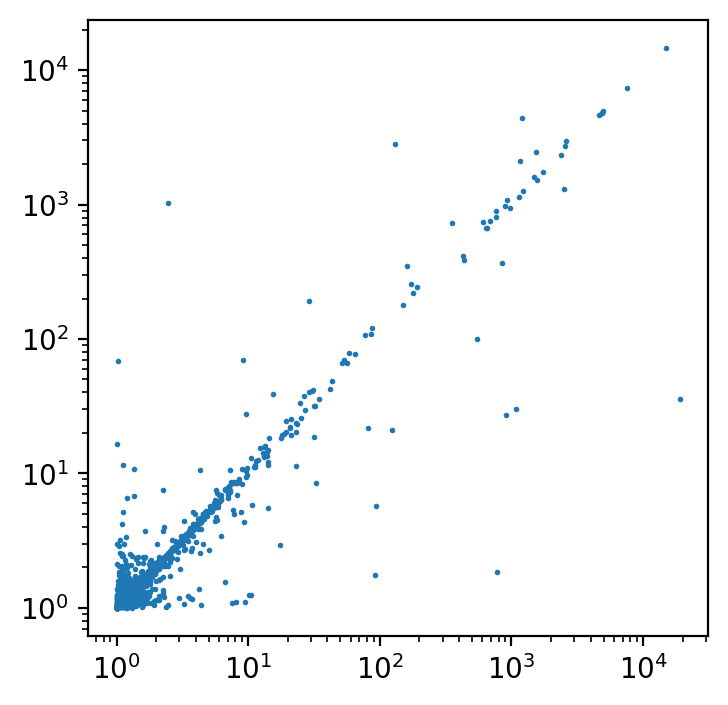

In [236]:
plt.figure(figsize=(4,4))
plt.scatter(comparison_ptrs_py_matlab_web.ptr_py, 
            comparison_ptrs_py_matlab_web.web_ptr, s=1)
plt.xscale('log')
plt.yscale('log')

# plt.title('PTR comparison between Matlab and Published Web')
# plt.xlabel("Matlab PTR")
# plt.ylabel("Published PTR")
